In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

CURRENT_DIR = Path.cwd()
STORAGE_DIR = CURRENT_DIR.parent / 'Data' / 'Processed'
file_path=STORAGE_DIR / 'Cleaned_EV_Vehicle_Specs.csv'


EV_Vehicle=pd.read_csv(file_path)

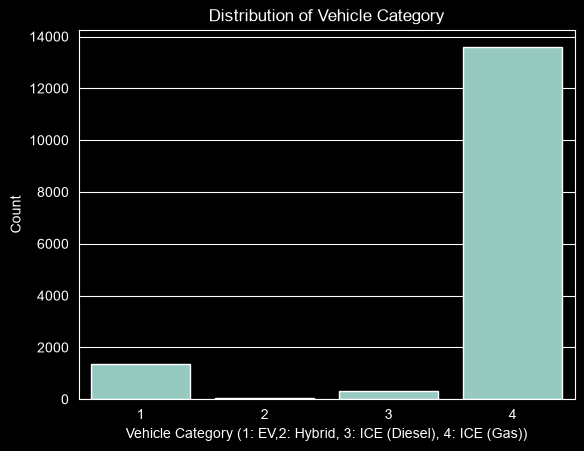

In [2]:
#Distribution of the target variable
sns.countplot(x='Vehicle_Category', data=EV_Vehicle)
plt.title('Distribution of Vehicle Category')
plt.xlabel('Vehicle Category (1: EV,2: Hybrid, 3: ICE (Diesel), 4: ICE (Gas))')
plt.ylabel('Count')
plt.show()
#Note that there is only one CNG car in the dataset, which may not be sufficient for training a model to classify CNG vehicles accurately. So we dropped the CNG category in the data cleaning step.

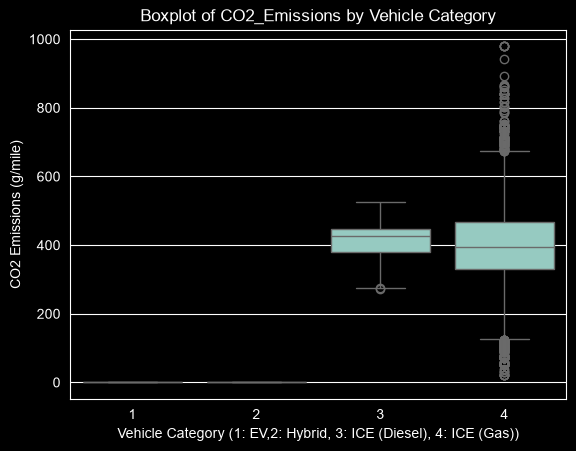

In [3]:
sns.boxplot(x='Vehicle_Category', y='CO2_Emissions_g_per_mile', data=EV_Vehicle)
plt.title('Boxplot of CO2_Emissions by Vehicle Category')
plt.xlabel('Vehicle Category (1: EV,2: Hybrid, 3: ICE (Diesel), 4: ICE (Gas))')
plt.ylabel('CO2 Emissions (g/mile)')
plt.show()
#From the boxplot, we can see that EVs have the lowest CO2 emissions, followed by hybrids, while ICE vehicles (both diesel and gas) have significantly higher CO2 emissions. This indicates a clear distinction in CO2 emissions between the different vehicle categories, which could be a useful feature for classification.

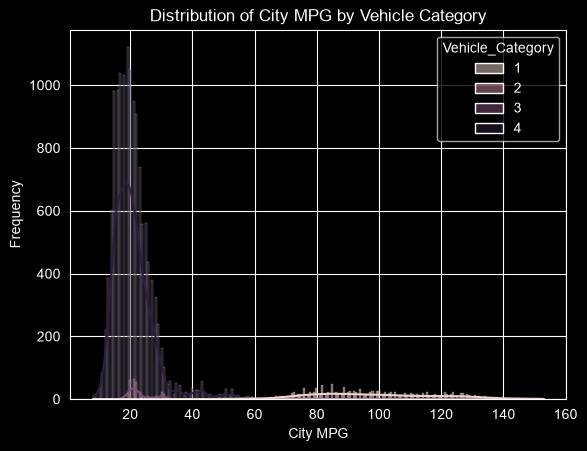

In [4]:
sns.histplot(x='City_MPG', hue='Vehicle_Category', data=EV_Vehicle, kde=True)
plt.title('Distribution of City MPG by Vehicle Category')
plt.xlabel('City MPG')
plt.ylabel('Frequency')
plt.show()
#The histogram shows that EVs have a much higher City MPG compared to hybrids and ICE vehicles. Hybrids have a moderate City MPG, while ICE vehicles (both diesel and gas) have significantly lower City MPG. This suggests that City MPG is a strong feature for distinguishing between the different vehicle categories, especially for identifying EVs.

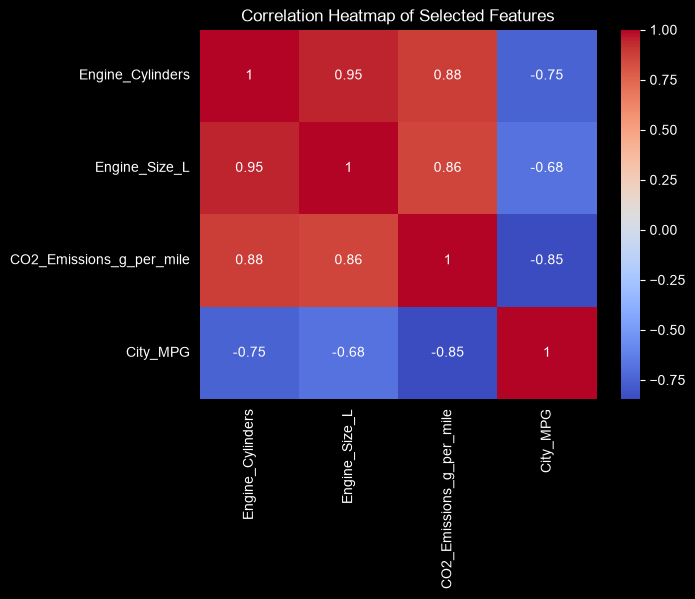

In [5]:
Variables=['Engine_Cylinders', 'Engine_Size_L', 'CO2_Emissions_g_per_mile', 'City_MPG']
sns.heatmap(EV_Vehicle[Variables].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Selected Features')
plt.show()
#The heatmap shows the correlation between the selected features. We can see that CO2 emissions have a strong negative correlation with City MPG, which is expected since vehicles with higher fuel efficiency tend to emit less CO2. Engine size and engine cylinders also show a positive correlation with CO2 emissions, indicating that larger engines tend to produce more emissions. These correlations can help us understand the relationships between the features and the target variable, which can be useful for feature selection and model building.

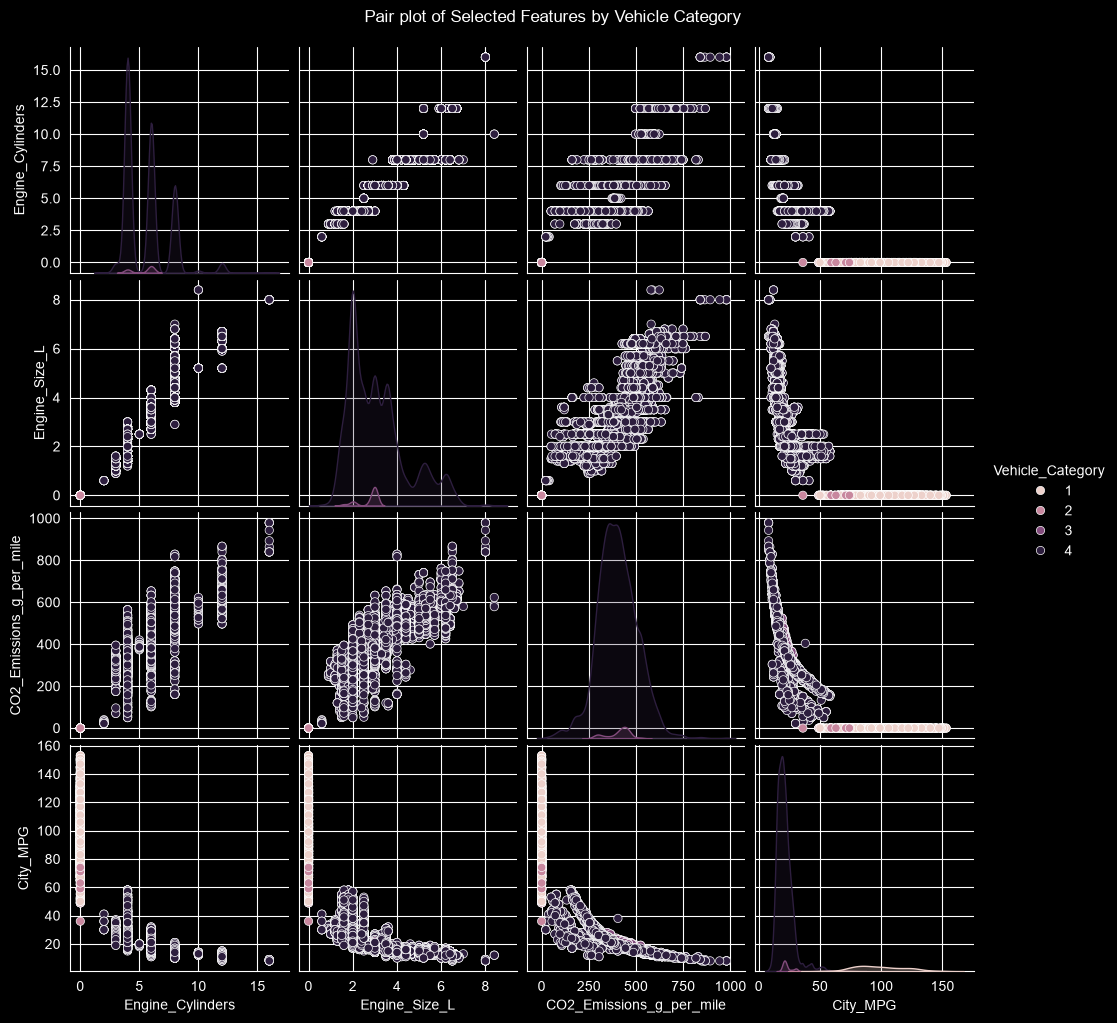

In [6]:
sns.pairplot(EV_Vehicle, hue='Vehicle_Category', vars=['Engine_Cylinders', 'Engine_Size_L', 'CO2_Emissions_g_per_mile', 'City_MPG'])
plt.suptitle('Pair plot of Selected Features by Vehicle Category', y=1.02)
plt.show()
#The pair plot shows the relationships between the selected features for each vehicle category. We can see that EVs tend to cluster in the region with low engine cylinders, small engine size, low CO2 emissions, and high City MPG. Hybrids are more spread out but generally have moderate values for these features. ICE vehicles (both diesel and gas) tend to cluster in the region with higher engine cylinders, larger engine size, higher CO2 emissions, and lower City MPG. This visualization helps us see how the different vehicle categories are distributed across the feature space, which can inform our modeling approach.